# Phish-Detect ML — Phase 3 : Modélisation

*2ème année Cycle d'Ingénieurs – Génie Informatique | Machine Learning | 2025–2026*

---

## Objectif de Phase 3

Entraîner et évaluer différents modèles de classification via validation croisée stratifiée.

### Protocole d'Entraînement 

✅ **Pour chaque modèle**, utiliser le **pipeline construit en Phase 2** (preprocessing + modèle)  
✅ **Validation croisée stratifiée à 5 splits** (StratifiedKFold)  
✅ **Reporter la moyenne ET l'écart-type** (σ) de la métrique principale (F1)  
✅ **Fixer le random_state partout** pour reproductibilité

---
## 1. Imports & Configuration

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import time
from datetime import datetime

# Scikit-learn
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
import joblib

warnings.filterwarnings('ignore')

# Configuration
PROJECT_ROOT = Path('..')
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.figsize': (14, 6), 'figure.dpi': 120, 'font.size': 11})
np.random.seed(42)

print('✓ Environnement configuré')

✓ Environnement configuré


---
## 2. Chargement Données Brutes & Preprocessor

In [108]:
# Charger dataset_engineered.parquet (données BRUTES - AVANT preprocessing)
parquet_path = DATA_DIR / 'dataset_engineered.parquet'
if not parquet_path.exists():
    raise FileNotFoundError(f'Fichier manquant : {parquet_path}\nExécuter d\'abord Phase 2')

df = pd.read_parquet(parquet_path)
print(f'✓ Dataset brut chargé : {df.shape}')

# Charger preprocessor
preprocessor_path = MODELS_DIR / 'preprocessor.joblib'
if not preprocessor_path.exists():
    raise FileNotFoundError(f'Fichier manquant : {preprocessor_path}\nExécuter d\'abord Phase 2')

preprocessor = joblib.load(preprocessor_path)
print(f'✓ Preprocessor chargé')

✓ Dataset brut chargé : (11000, 24)
✓ Preprocessor chargé


---
## 3. Préparation des Données

In [109]:
# Exclure url (identifiant), garder le reste pour preprocessing
df_features = df.drop(columns=['url'])

# Split X/y
X = df_features.drop(columns=['is_phishing'])
y = df_features['is_phishing']

print(f'✓ X : {X.shape}, y : {y.shape}')
print(f'✓ Pas de NaN')

# Distribution
class_counts = y.value_counts().sort_index()
print(f'\nClasses :')
for label, count in class_counts.items():
    print(f'  {label} : {count:,} ({count/len(y)*100:.1f}%)')

✓ X : (11000, 22), y : (11000,)
✓ Pas de NaN

Classes :
  0 : 9,000 (81.8%)
  1 : 2,000 (18.2%)


---
## 4. Configuration Validation Croisée

In [110]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'✓ StratifiedKFold(5, shuffle=True, random_state=42)')

print(f'\n  Aperçu des folds :')
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    phish_train = y.iloc[train_idx].mean() * 100
    phish_val = y.iloc[val_idx].mean() * 100
    print(f'    Fold {fold_idx+1} : Train={len(train_idx):,} ({phish_train:.1f}% phishing) | Val={len(val_idx):,} ({phish_val:.1f}% phishing)')

✓ StratifiedKFold(5, shuffle=True, random_state=42)

  Aperçu des folds :
    Fold 1 : Train=8,800 (18.2% phishing) | Val=2,200 (18.2% phishing)
    Fold 2 : Train=8,800 (18.2% phishing) | Val=2,200 (18.2% phishing)
    Fold 3 : Train=8,800 (18.2% phishing) | Val=2,200 (18.2% phishing)
    Fold 4 : Train=8,800 (18.2% phishing) | Val=2,200 (18.2% phishing)
    Fold 5 : Train=8,800 (18.2% phishing) | Val=2,200 (18.2% phishing)


---
## 5. Pipeline SVM (RBF)

In [111]:
svm_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42, verbose=0))
])

print('✓ Pipeline SVM créé')
print('  SVC(kernel=rbf, C=1.0, random_state=42)')

✓ Pipeline SVM créé
  SVC(kernel=rbf, C=1.0, random_state=42)


---
## 6. Pipeline MLP

In [112]:
mlp_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, early_stopping=True, validation_fraction=0.2, n_iter_no_change=10, random_state=42, verbose=0))
])

print('✓ Pipeline MLP créé')
print('  MLPClassifier(hidden_layers=(100,50), random_state=42)')

✓ Pipeline MLP créé
  MLPClassifier(hidden_layers=(100,50), random_state=42)


---
## 7. Fonction Validation Croisée

In [113]:
def validate_pipeline(pipeline, X, y, cv, pipeline_name):
    results = {'F1': [], 'Precision': [], 'Recall': [], 'ROC-AUC': []}
    fold_details = []
    
    print(f'\n{"="*75}')
    print(f'VALIDATION CROISÉE : {pipeline_name}')
    print(f'{"="*75}')
    
    start_time = time.time()
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        fold_start = time.time()
        
        X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
        
        pipeline.fit(X_fold_train, y_fold_train)
        y_pred = pipeline.predict(X_fold_val)
        
        try:
            y_proba = pipeline.predict_proba(X_fold_val)[:, 1]
        except:
            y_proba = None
        
        fold_metrics = {
            'F1': f1_score(y_fold_val, y_pred, zero_division=0),
            'Precision': precision_score(y_fold_val, y_pred, zero_division=0),
            'Recall': recall_score(y_fold_val, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_fold_val, y_proba) if y_proba is not None else np.nan,
        }
        
        for metric, value in fold_metrics.items():
            results[metric].append(value)
        
        fold_time = time.time() - fold_start
        fold_details.append({'Fold': fold_idx + 1, **fold_metrics, 'Time (s)': fold_time})
        
        print(f'  Fold {fold_idx+1}/5 | F1={fold_metrics["F1"]:.4f} | Prec={fold_metrics["Precision"]:.4f} | Rec={fold_metrics["Recall"]:.4f} | ROC-AUC={fold_metrics["ROC-AUC"]:.4f}')
    
    total_time = time.time() - start_time
    
    summary = {}
    for metric in results.keys():
        scores = np.array(results[metric])
        summary[metric] = {'mean': np.mean(scores), 'std': np.std(scores, ddof=1), 'scores': scores}
    
    print(f'\n{"─"*75}')
    print(f'RÉSUMÉ')
    print(f'{"─"*75}')
    for metric in ['F1', 'Precision', 'Recall', 'ROC-AUC']:
        print(f'{metric:15s} : {summary[metric]["mean"]:.4f} ± {summary[metric]["std"]:.4f}')
    print(f'Temps : {total_time:.2f}s')
    print(f'{"="*75}\n')
    
    return summary, pd.DataFrame(fold_details)

print('✓ Fonction définie')

✓ Fonction définie


---
## 8. Validation Croisée — SVM

In [114]:
svm_results, svm_folds = validate_pipeline(svm_pipeline, X, y, cv, 'SVM (RBF, C=1.0)')
print('\nDétails par fold (SVM) :')
print(svm_folds.to_string(index=False))


VALIDATION CROISÉE : SVM (RBF, C=1.0)
  Fold 1/5 | F1=0.9886 | Prec=1.0000 | Rec=0.9775 | ROC-AUC=0.9992
  Fold 2/5 | F1=0.9822 | Prec=1.0000 | Rec=0.9650 | ROC-AUC=0.9982
  Fold 3/5 | F1=0.9848 | Prec=1.0000 | Rec=0.9700 | ROC-AUC=0.9986
  Fold 4/5 | F1=0.9861 | Prec=1.0000 | Rec=0.9725 | ROC-AUC=0.9994
  Fold 5/5 | F1=0.9822 | Prec=1.0000 | Rec=0.9650 | ROC-AUC=0.9982

───────────────────────────────────────────────────────────────────────────
RÉSUMÉ
───────────────────────────────────────────────────────────────────────────
F1              : 0.9848 ± 0.0027
Precision       : 1.0000 ± 0.0000
Recall          : 0.9700 ± 0.0053
ROC-AUC         : 0.9987 ± 0.0006
Temps : 9.67s


Détails par fold (SVM) :
 Fold       F1  Precision  Recall  ROC-AUC  Time (s)
    1 0.988622        1.0  0.9775 0.999168  1.921335
    2 0.982188        1.0  0.9650 0.998158  2.111883
    3 0.984772        1.0  0.9700 0.998650  1.849572
    4 0.986058        1.0  0.9725 0.999394  1.926958
    5 0.982188        1.

---
## 9. Validation Croisée — MLP

In [115]:
mlp_results, mlp_folds = validate_pipeline(mlp_pipeline, X, y, cv, 'MLP (hidden=(100,50))')
print('\nDétails par fold (MLP) :')
print(mlp_folds.to_string(index=False))


VALIDATION CROISÉE : MLP (hidden=(100,50))
  Fold 1/5 | F1=0.9874 | Prec=0.9924 | Rec=0.9825 | ROC-AUC=0.9996
  Fold 2/5 | F1=0.9874 | Prec=0.9974 | Rec=0.9775 | ROC-AUC=0.9993
  Fold 3/5 | F1=0.9810 | Prec=0.9923 | Rec=0.9700 | ROC-AUC=0.9993
  Fold 4/5 | F1=0.9925 | Prec=0.9900 | Rec=0.9950 | ROC-AUC=0.9999
  Fold 5/5 | F1=0.9861 | Prec=0.9949 | Rec=0.9775 | ROC-AUC=0.9998

───────────────────────────────────────────────────────────────────────────
RÉSUMÉ
───────────────────────────────────────────────────────────────────────────
F1              : 0.9869 ± 0.0041
Precision       : 0.9934 ± 0.0028
Recall          : 0.9805 ± 0.0093
ROC-AUC         : 0.9996 ± 0.0003
Temps : 6.57s


Détails par fold (MLP) :
 Fold       F1  Precision  Recall  ROC-AUC  Time (s)
    1 0.987437   0.992424  0.9825 0.999576  1.006513
    2 0.987374   0.997449  0.9775 0.999322  0.976523
    3 0.981037   0.992327  0.9700 0.999304  1.015352
    4 0.992519   0.990050  0.9950 0.999865  1.846853
    5 0.986129   0.

---
## 10. Tableau Récapitulatif

In [116]:
metrics_list = ['F1', 'Precision', 'Recall', 'ROC-AUC']

print('\n' + '='*95)
print('TABLEAU RÉCAPITULATIF — Phase 3.1 (CV-5, Sans Rééquilibrage)')
print('='*95)
print(f'{"Métrique":20s} | {"SVM (RBF)":40s} | {"MLP (100,50)":40s}')
print(f'{"─"*20}-+-{"─"*40}-+-{"─"*40}')

for metric in metrics_list:
    svm_mean, svm_std = svm_results[metric]['mean'], svm_results[metric]['std']
    mlp_mean, mlp_std = mlp_results[metric]['mean'], mlp_results[metric]['std']
    print(f'{metric:20s} | {svm_mean:.4f} ± {svm_std:.4f}{" "*20} | {mlp_mean:.4f} ± {mlp_std:.4f}{" "*20}')

print('='*95)
print(f'Configuration : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)')


TABLEAU RÉCAPITULATIF — Phase 3.1 (CV-5, Sans Rééquilibrage)
Métrique             | SVM (RBF)                                | MLP (100,50)                            
────────────────────-+-────────────────────────────────────────-+-────────────────────────────────────────
F1                   | 0.9848 ± 0.0027                     | 0.9869 ± 0.0041                    
Precision            | 1.0000 ± 0.0000                     | 0.9934 ± 0.0028                    
Recall               | 0.9700 ± 0.0053                     | 0.9805 ± 0.0093                    
ROC-AUC              | 0.9987 ± 0.0006                     | 0.9996 ± 0.0003                    
Configuration : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


---
## 11. Sauvegarde des Résultats

In [117]:
export_data = []
for model_name, results_dict in [('SVM', svm_results), ('MLP', mlp_results)]:
    for metric in metrics_list:
        export_data.append({
            'Model': model_name,
            'Strategy': 'No Rebalancing',
            'Metric': metric,
            'Mean': results_dict[metric]['mean'],
            'Std': results_dict[metric]['std'],
            'Min': results_dict[metric]['scores'].min(),
            'Max': results_dict[metric]['scores'].max(),
        })

summary_df = pd.DataFrame(export_data)
summary_df.to_csv(RESULTS_DIR / 'phase3_results_summary.csv', index=False)
svm_folds.to_csv(RESULTS_DIR / 'svm_fold_details.csv', index=False)
mlp_folds.to_csv(RESULTS_DIR / 'mlp_fold_details.csv', index=False)

print(f'✓ Résultats sauvegardés')
print(summary_df.to_string(index=False))

✓ Résultats sauvegardés
Model       Strategy    Metric     Mean      Std      Min      Max
  SVM No Rebalancing        F1 0.984766 0.002731 0.982188 0.988622
  SVM No Rebalancing Precision 1.000000 0.000000 1.000000 1.000000
  SVM No Rebalancing    Recall 0.970000 0.005303 0.965000 0.977500
  SVM No Rebalancing   ROC-AUC 0.998708 0.000565 0.998158 0.999394
  MLP No Rebalancing        F1 0.986899 0.004094 0.981037 0.992519
  MLP No Rebalancing Precision 0.993432 0.002828 0.990050 0.997449
  MLP No Rebalancing    Recall 0.980500 0.009253 0.970000 0.995000
  MLP No Rebalancing   ROC-AUC 0.999574 0.000261 0.999304 0.999865


---
## 12. Visualisations

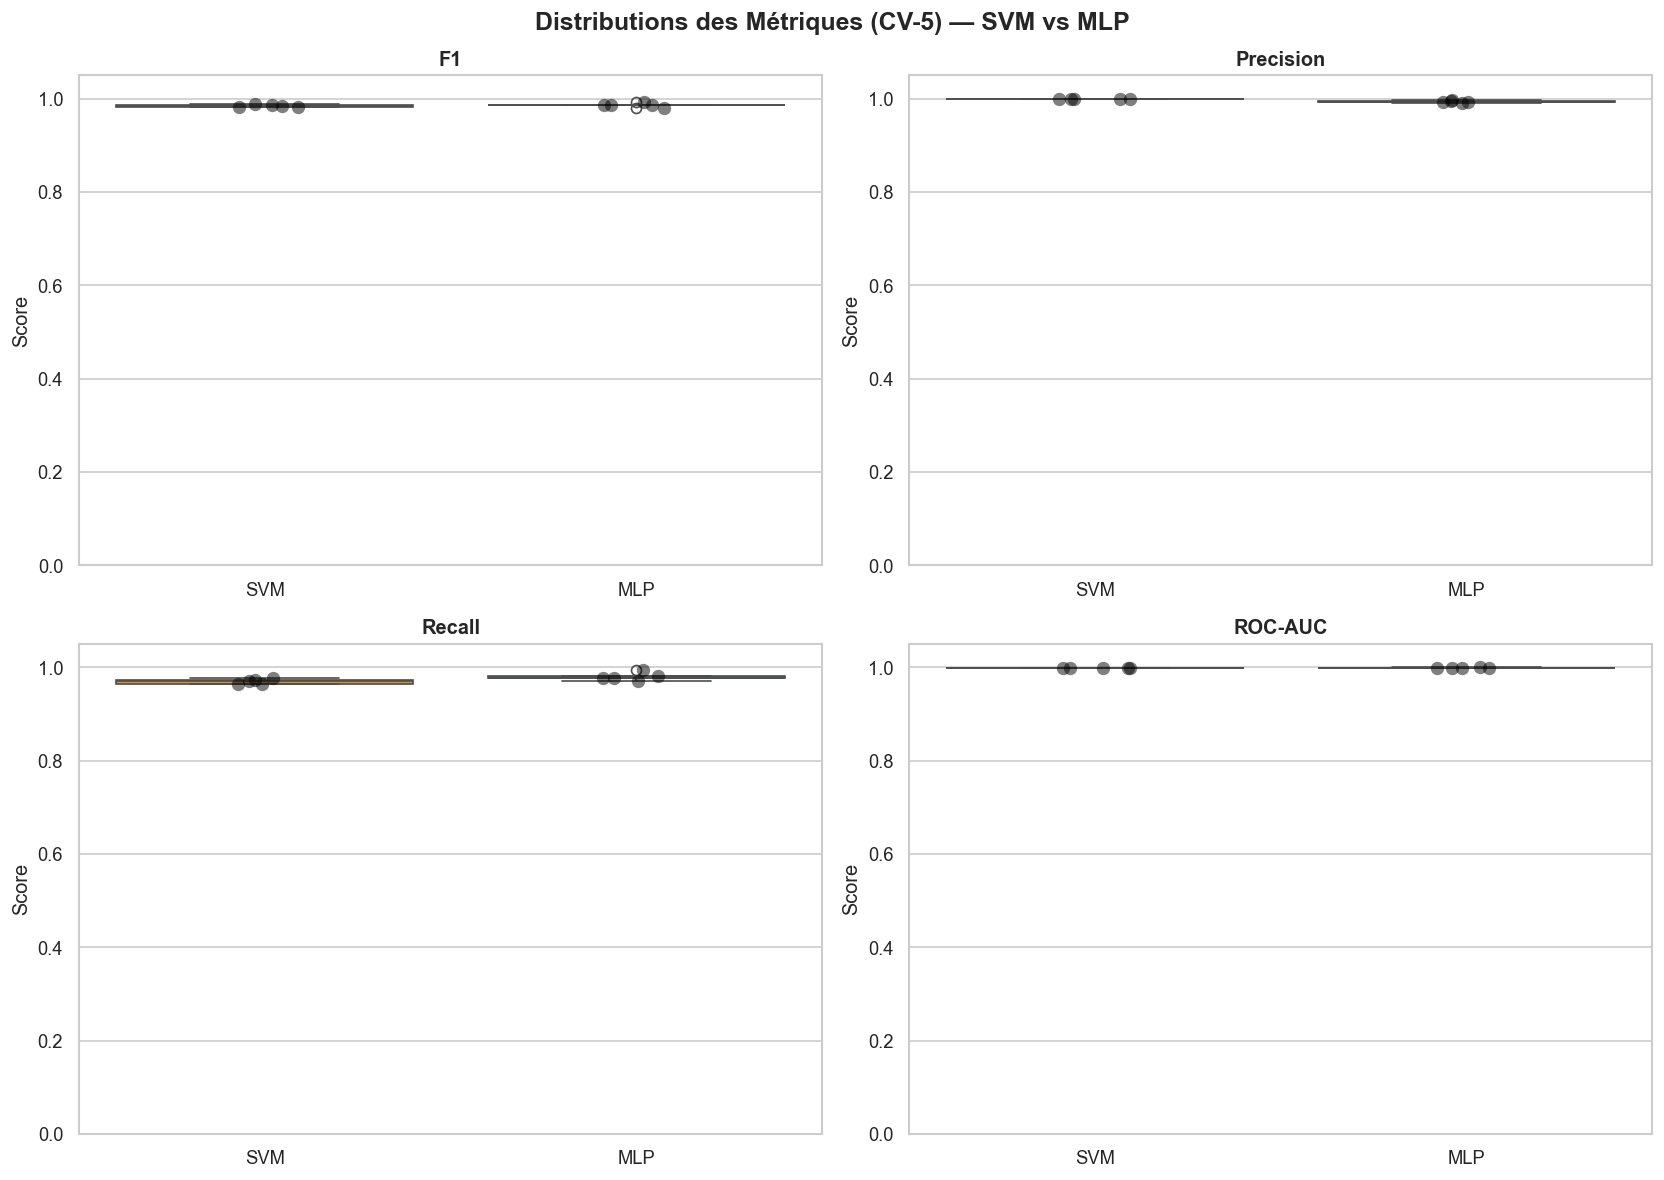

✓ Visualisation sauvegardée


In [118]:
plot_data = []
for fold_idx in range(5):
    for metric in metrics_list:
        plot_data.append({'Model': 'SVM', 'Metric': metric, 'Fold': f'Fold {fold_idx+1}', 'Score': svm_results[metric]['scores'][fold_idx]})
        plot_data.append({'Model': 'MLP', 'Metric': metric, 'Fold': f'Fold {fold_idx+1}', 'Score': mlp_results[metric]['scores'][fold_idx]})

plot_df = pd.DataFrame(plot_data)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distributions des Métriques (CV-5) — SVM vs MLP', fontsize=15, fontweight='bold')

for idx, metric in enumerate(metrics_list):
    ax = axes[idx // 2, idx % 2]
    metric_data = plot_df[plot_df['Metric'] == metric]
    sns.boxplot(data=metric_data, x='Model', y='Score', palette=['#FF9800', '#2196F3'], ax=ax)
    sns.stripplot(data=metric_data, x='Model', y='Score', size=8, color='black', alpha=0.5, ax=ax)
    ax.set_title(f'{metric}', fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xlabel('')
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase3_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Visualisation sauvegardée')

---
## 13. F1 par Fold

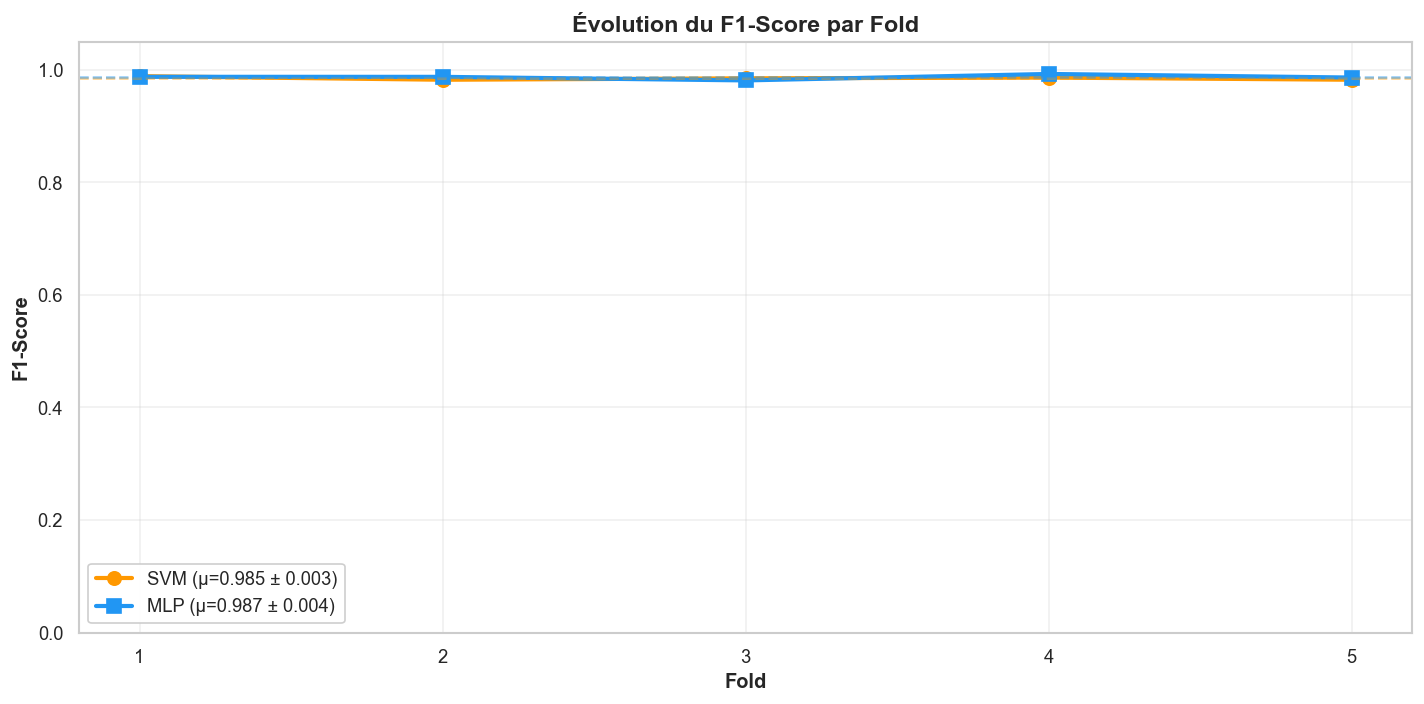

✓ Visualisation sauvegardée


In [119]:
fig, ax = plt.subplots(figsize=(12, 6))
folds = np.arange(1, 6)

ax.plot(folds, svm_results['F1']['scores'], 'o-', linewidth=2.5, markersize=8,
        label=f'SVM (μ={svm_results["F1"]["mean"]:.3f} ± {svm_results["F1"]["std"]:.3f})', color='#FF9800')
ax.plot(folds, mlp_results['F1']['scores'], 's-', linewidth=2.5, markersize=8,
        label=f'MLP (μ={mlp_results["F1"]["mean"]:.3f} ± {mlp_results["F1"]["std"]:.3f})', color='#2196F3')

ax.axhline(svm_results['F1']['mean'], color='#FF9800', linestyle='--', alpha=0.5, linewidth=1.5)
ax.axhline(mlp_results['F1']['mean'], color='#2196F3', linestyle='--', alpha=0.5, linewidth=1.5)

ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Évolution du F1-Score par Fold', fontsize=14, fontweight='bold')
ax.set_xticks(folds)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase3_f1_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Visualisation sauvegardée')

---
## 14. Rapport Final

In [120]:
print('\n' + '='*95)
print('RAPPORT FINAL — PHASE 3.1(Pour SVM et MLP)')
print('='*95)
print(f'\n📊 DATASET')
print(f'  Total : {len(X):,} samples')
print(f'  Features : {X.shape[1]}')
print(f'  Classe 0 (Légitime) : {(y == 0).sum():,}')
print(f'  Classe 1 (Phishing) : {(y == 1).sum():,}')

print(f'\n🎯 RÉSULTATS SVM (RBF, C=1.0)')
for metric in metrics_list:
    mean = svm_results[metric]['mean']
    std = svm_results[metric]['std']
    print(f'  {metric:15s} = {mean:.4f} ± {std:.4f}')

print(f'\n🎯 RÉSULTATS MLP (hidden=(100,50))')
for metric in metrics_list:
    mean = mlp_results[metric]['mean']
    std = mlp_results[metric]['std']
    print(f'  {metric:15s} = {mean:.4f} ± {std:.4f}')

f1_svm = svm_results['F1']['mean']
f1_mlp = mlp_results['F1']['mean']
winner = 'MLP' if f1_mlp > f1_svm else 'SVM'
print(f'\n📈 MEILLEUR : {winner} (F1 : {max(f1_svm, f1_mlp):.4f})')
print(f'\n✅ Fichiers générés :')
print(f'  - results/phase3_results_summary.csv')
print(f'  - results/svm_fold_details.csv')
print(f'  - results/mlp_fold_details.csv')
print(f'  - results/phase3_metrics_comparison.png')
print(f'  - results/phase3_f1_evolution.png')
print('\n' + '='*95)


RAPPORT FINAL — PHASE 3.1(Pour SVM et MLP)

📊 DATASET
  Total : 11,000 samples
  Features : 22
  Classe 0 (Légitime) : 9,000
  Classe 1 (Phishing) : 2,000

🎯 RÉSULTATS SVM (RBF, C=1.0)
  F1              = 0.9848 ± 0.0027
  Precision       = 1.0000 ± 0.0000
  Recall          = 0.9700 ± 0.0053
  ROC-AUC         = 0.9987 ± 0.0006

🎯 RÉSULTATS MLP (hidden=(100,50))
  F1              = 0.9869 ± 0.0041
  Precision       = 0.9934 ± 0.0028
  Recall          = 0.9805 ± 0.0093
  ROC-AUC         = 0.9996 ± 0.0003

📈 MEILLEUR : MLP (F1 : 0.9869)

✅ Fichiers générés :
  - results/phase3_results_summary.csv
  - results/svm_fold_details.csv
  - results/mlp_fold_details.csv
  - results/phase3_metrics_comparison.png
  - results/phase3_f1_evolution.png



---
## 15. Comparaison des Stratégies de Gestion du Déséquilibre
Évaluation de 3 stratégies pour SVM et MLP : Sans rééquilibrage (Class Weight pour SVM), SMOTE, et Undersampling.

In [121]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# 1. SVM - Sans rééquilibrage (Class Weight)
svm_cw_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced', random_state=42, verbose=0))
])

# 2. SVM - SMOTE
svm_smote_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42, verbose=0))
])

# 3. SVM - Undersampling
svm_us_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42, verbose=0))
])

# 4. MLP - Sans rééquilibrage (Class Weight non supporté nativement, on utilise le modèle de base)
mlp_base_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, early_stopping=True, validation_fraction=0.2, n_iter_no_change=10, random_state=42, verbose=0))
])

# 5. MLP - SMOTE
mlp_smote_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, early_stopping=True, validation_fraction=0.2, n_iter_no_change=10, random_state=42, verbose=0))
])

# 6. MLP - Undersampling
mlp_us_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, early_stopping=True, validation_fraction=0.2, n_iter_no_change=10, random_state=42, verbose=0))
])
print('Pipelines configurés avec ImbPipeline.')

Pipelines configurés avec ImbPipeline.


In [122]:
pipelines = {
    'SVM - Class Weight': svm_cw_pipeline,
    'SVM - SMOTE': svm_smote_pipeline,
    'SVM - Undersampling': svm_us_pipeline,
    'MLP - Sans rééq.': mlp_base_pipeline,
    'MLP - SMOTE': mlp_smote_pipeline,
    'MLP - Undersampling': mlp_us_pipeline
}

results_comparison = {}
for name, pipe in pipelines.items():
    res, _ = validate_pipeline(pipe, X, y, cv, name)
    results_comparison[name] = res['F1']


VALIDATION CROISÉE : SVM - Class Weight
  Fold 1/5 | F1=0.9887 | Prec=0.9924 | Rec=0.9850 | ROC-AUC=0.9995
  Fold 2/5 | F1=0.9861 | Prec=0.9974 | Rec=0.9750 | ROC-AUC=0.9992
  Fold 3/5 | F1=0.9824 | Prec=0.9898 | Rec=0.9750 | ROC-AUC=0.9993
  Fold 4/5 | F1=0.9912 | Prec=1.0000 | Rec=0.9825 | ROC-AUC=0.9997
  Fold 5/5 | F1=0.9848 | Prec=0.9949 | Rec=0.9750 | ROC-AUC=0.9991

───────────────────────────────────────────────────────────────────────────
RÉSUMÉ
───────────────────────────────────────────────────────────────────────────
F1              : 0.9866 ± 0.0034
Precision       : 0.9949 ± 0.0040
Recall          : 0.9785 ± 0.0049
ROC-AUC         : 0.9994 ± 0.0003
Temps : 13.18s


VALIDATION CROISÉE : SVM - SMOTE
  Fold 1/5 | F1=0.9887 | Prec=0.9949 | Rec=0.9825 | ROC-AUC=0.9988
  Fold 2/5 | F1=0.9824 | Prec=0.9898 | Rec=0.9750 | ROC-AUC=0.9982
  Fold 3/5 | F1=0.9823 | Prec=0.9923 | Rec=0.9725 | ROC-AUC=0.9985
  Fold 4/5 | F1=0.9912 | Prec=1.0000 | Rec=0.9825 | ROC-AUC=0.9994
  Fold 5/5

In [123]:
import pandas as pd

# Construction du tableau croisé 
data_table = {
    'Modèle': ['Modèle 1 (SVM)', 'Modèle 2 (MLP)'],
    'Sans rééq. (class_weight)': [
        f"{results_comparison['SVM - Class Weight']['mean']:.4f} ± {results_comparison['SVM - Class Weight']['std']:.4f}",
        f"{results_comparison['MLP - Sans rééq.']['mean']:.4f} ± {results_comparison['MLP - Sans rééq.']['std']:.4f}"
    ],
    'SMOTE': [
        f"{results_comparison['SVM - SMOTE']['mean']:.4f} ± {results_comparison['SVM - SMOTE']['std']:.4f}",
        f"{results_comparison['MLP - SMOTE']['mean']:.4f} ± {results_comparison['MLP - SMOTE']['std']:.4f}"
    ],
    'Undersampling': [
        f"{results_comparison['SVM - Undersampling']['mean']:.4f} ± {results_comparison['SVM - Undersampling']['std']:.4f}",
        f"{results_comparison['MLP - Undersampling']['mean']:.4f} ± {results_comparison['MLP - Undersampling']['std']:.4f}"
    ]
}

df_comparison = pd.DataFrame(data_table)

print("\nTABLEAU COMPARATIF DES STRATÉGIES DE RÉÉQUILIBRAGE (Score F1)")
print("="*85)
print(df_comparison.to_string(index=False))
print("="*85)

df_comparison.to_csv(RESULTS_DIR / 'rebalancing_comparison.csv', index=False)
print("✓ Tableau exporté vers results/rebalancing_comparison.csv")



TABLEAU COMPARATIF DES STRATÉGIES DE RÉÉQUILIBRAGE (Score F1)
        Modèle Sans rééq. (class_weight)           SMOTE   Undersampling
Modèle 1 (SVM)           0.9866 ± 0.0034 0.9859 ± 0.0039 0.9774 ± 0.0039
Modèle 2 (MLP)           0.9869 ± 0.0041 0.9923 ± 0.0020 0.9773 ± 0.0112
✓ Tableau exporté vers results/rebalancing_comparison.csv


---
## 16. LightGBM — Imports Supplémentaires

In [124]:
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

print('✓ LightGBM & Imblearn chargés')

✓ LightGBM & Imblearn chargés


---
## 17. LightGBM — Baseline (Scale_pos_weight)

In [125]:
lgbm_baseline_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=4.5,
        verbose=-1,
        num_leaves=31,
        learning_rate=0.05,
        n_estimators=200
    ))
])

print('✓ Pipeline LightGBM baseline créé')
print('  LGBMClassifier(scale_pos_weight=4.5, random_state=42)')
print('  → Rééquilibrage natif via poids des classes')

✓ Pipeline LightGBM baseline créé
  LGBMClassifier(scale_pos_weight=4.5, random_state=42)
  → Rééquilibrage natif via poids des classes


---
## 18. LightGBM × SMOTE

In [126]:
lgbm_smote_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=1.0,
        verbose=-1,
        num_leaves=31,
        learning_rate=0.05,
        n_estimators=200
    ))
])

print('✓ Pipeline LightGBM + SMOTE créé')
print('  SMOTE(k_neighbors=5, random_state=42) + LGBMClassifier')
print('  → Suréchantillonnage de la classe minoritaire')

✓ Pipeline LightGBM + SMOTE créé
  SMOTE(k_neighbors=5, random_state=42) + LGBMClassifier
  → Suréchantillonnage de la classe minoritaire


---
## 19. LightGBM × Undersampling

In [127]:
lgbm_us_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('classifier', LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=1.0,
        verbose=-1,
        num_leaves=31,
        learning_rate=0.05,
        n_estimators=200
    ))
])

print('✓ Pipeline LightGBM + Undersampling créé')
print('  RandomUnderSampler(random_state=42) + LGBMClassifier')
print('  → Sous-échantillonnage de la classe majoritaire')

✓ Pipeline LightGBM + Undersampling créé
  RandomUnderSampler(random_state=42) + LGBMClassifier
  → Sous-échantillonnage de la classe majoritaire


---
## 20. Validation Croisée — LightGBM × 3 Stratégies

In [128]:
pipelines_lgbm = {
    'LightGBM - Class Weight': lgbm_baseline_pipeline,
    'LightGBM - SMOTE': lgbm_smote_pipeline,
    'LightGBM - Undersampling': lgbm_us_pipeline
}

for name, pipe in pipelines_lgbm.items():
    res, _ = validate_pipeline(pipe, X, y, cv, name)
    results_comparison[name] = res['F1']

print('\n✓ Validation croisée des 3 stratégies LightGBM complétée')
print(f'  Résultats stockés dans results_comparison : {list(pipelines_lgbm.keys())}')


VALIDATION CROISÉE : LightGBM - Class Weight
  Fold 1/5 | F1=0.9950 | Prec=0.9925 | Rec=0.9975 | ROC-AUC=1.0000
  Fold 2/5 | F1=0.9962 | Prec=0.9975 | Rec=0.9950 | ROC-AUC=1.0000
  Fold 3/5 | F1=0.9950 | Prec=0.9925 | Rec=0.9975 | ROC-AUC=1.0000
  Fold 4/5 | F1=0.9963 | Prec=0.9950 | Rec=0.9975 | ROC-AUC=0.9999
  Fold 5/5 | F1=0.9937 | Prec=1.0000 | Rec=0.9875 | ROC-AUC=0.9999

───────────────────────────────────────────────────────────────────────────
RÉSUMÉ
───────────────────────────────────────────────────────────────────────────
F1              : 0.9952 ± 0.0011
Precision       : 0.9955 ± 0.0032
Recall          : 0.9950 ± 0.0043
ROC-AUC         : 1.0000 ± 0.0000
Temps : 3.05s


VALIDATION CROISÉE : LightGBM - SMOTE
  Fold 1/5 | F1=0.9938 | Prec=0.9877 | Rec=1.0000 | ROC-AUC=1.0000
  Fold 2/5 | F1=0.9975 | Prec=1.0000 | Rec=0.9950 | ROC-AUC=1.0000
  Fold 3/5 | F1=0.9963 | Prec=0.9926 | Rec=1.0000 | ROC-AUC=1.0000
  Fold 4/5 | F1=0.9963 | Prec=0.9950 | Rec=0.9975 | ROC-AUC=0.9975
 

---
## 21. Tableau Comparatif Final — Phase 3.2 (4 Modèles)

In [130]:
comparison_data = {
    'Modèle': ['LightGBM', 'Random Forest (M2) - À compléter', 'SVM', 'MLP'],
    'Sans rééq. (class_weight)': [
        f"{results_comparison['LightGBM - Class Weight']['mean']:.4f} ± {results_comparison['LightGBM - Class Weight']['std']:.4f}",
        'En attente M2',
        f"{results_comparison['SVM - Class Weight']['mean']:.4f} ± {results_comparison['SVM - Class Weight']['std']:.4f}",
        f"{results_comparison['MLP - Sans rééq.']['mean']:.4f} ± {results_comparison['MLP - Sans rééq.']['std']:.4f}"
    ],
    'SMOTE': [
        f"{results_comparison['LightGBM - SMOTE']['mean']:.4f} ± {results_comparison['LightGBM - SMOTE']['std']:.4f}",
        'En attente M2',
        f"{results_comparison['SVM - SMOTE']['mean']:.4f} ± {results_comparison['SVM - SMOTE']['std']:.4f}",
        f"{results_comparison['MLP - SMOTE']['mean']:.4f} ± {results_comparison['MLP - SMOTE']['std']:.4f}"
    ],
    'Undersampling': [
        f"{results_comparison['LightGBM - Undersampling']['mean']:.4f} ± {results_comparison['LightGBM - Undersampling']['std']:.4f}",
        'En attente M2',
        f"{results_comparison['SVM - Undersampling']['mean']:.4f} ± {results_comparison['SVM - Undersampling']['std']:.4f}",
        f"{results_comparison['MLP - Undersampling']['mean']:.4f} ± {results_comparison['MLP - Undersampling']['std']:.4f}"
    ]
}

df_comparison_final = pd.DataFrame(comparison_data)

print("\n" + "="*110)
print("TABLEAU COMPARATIF COMPLET — STRATÉGIES DE RÉÉQUILIBRAGE (Score F1 ± σ)")
print("="*110)
print(df_comparison_final.to_string(index=False))
print("="*110)

df_comparison_final.to_csv(RESULTS_DIR / 'rebalancing_comparison.csv', index=False)
print("\n✓ Tableau mis à jour et exporté vers results/rebalancing_comparison.csv")
print(f"  → 4 modèles × 3 stratégies (Random Forest à compléter par M2)")


TABLEAU COMPARATIF COMPLET — STRATÉGIES DE RÉÉQUILIBRAGE (Score F1 ± σ)
                          Modèle Sans rééq. (class_weight)           SMOTE   Undersampling
                        LightGBM           0.9952 ± 0.0011 0.9958 ± 0.0014 0.9913 ± 0.0015
Random Forest (M2) - À compléter             En attente M2   En attente M2   En attente M2
                             SVM           0.9866 ± 0.0034 0.9859 ± 0.0039 0.9774 ± 0.0039
                             MLP           0.9869 ± 0.0041 0.9923 ± 0.0020 0.9773 ± 0.0112

✓ Tableau mis à jour et exporté vers results/rebalancing_comparison.csv
  → 4 modèles × 3 stratégies (Random Forest à compléter par M2)
